Dataset Loaded Successfully
Shape: (33306, 14)
   Report Number     Date Reported Date of Occurrence Time of Occurrence  \
0              1  01-02-2020 00:00   01-01-2020 00:00   01-01-2020 01:11   
1              2  01-01-2020 19:00   01-01-2020 01:00   01-01-2020 06:26   
2              3  01-02-2020 05:00   01-01-2020 02:00   01-01-2020 14:30   
3              4  01-01-2020 05:00   01-01-2020 03:00   01-01-2020 14:46   
4              5  01-01-2020 21:00   01-01-2020 04:00   01-01-2020 16:51   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    Identity Theft          16             M   
1    Chennai         128          Homicide          37             M   
2   Ludhiana         271        Kidnapping          48             F   
3       Pune         170          Burglary          49             F   
4       Pune         421         Vandalism          30             F   

    Weapon Used   Crime Domain  Police Deployed Case Closed  Da

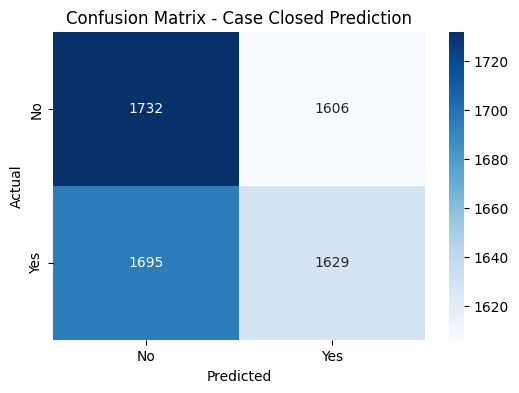

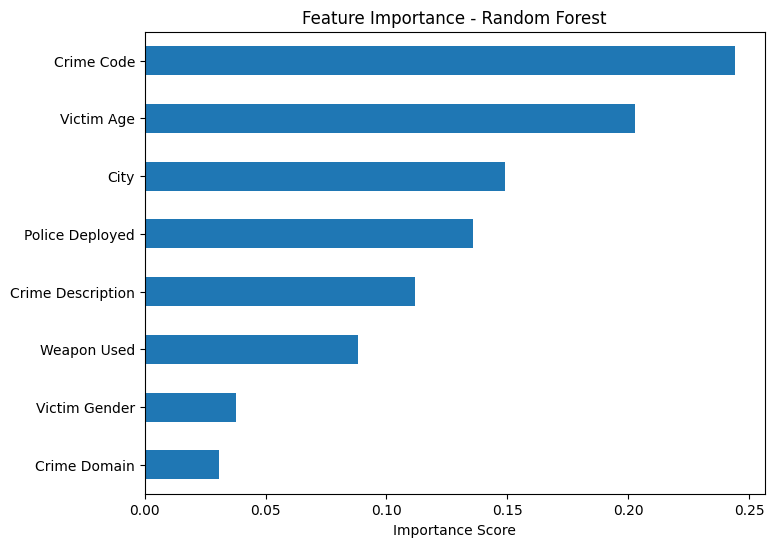

Model saved successfully


In [ ]:
# ==============================
# RANDOM FOREST - CASE CLOSED
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# STEP 1: Load Dataset
file_path = "cleaned_crime_dataset_india.csv"   # update path if needed
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print(df.head())

# STEP 2: Drop Non-Predictive / Leakage Columns
df.drop(
    columns=[
        "Report Number",
        "Date Reported",
        "Date of Occurrence",
        "Time of Occurrence",
        "Date Case Closed"
    ],
    inplace=True,
    errors="ignore"
)

# STEP 3: Encode Categorical Columns
label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Label Encoding Completed")

# STEP 4: Define Features and Target
X = df.drop(columns=["Case Closed"])
y = df["Case Closed"]

# STEP 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# STEP 6: Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# STEP 7: Predictions
y_pred = rf_model.predict(X_test)

# STEP 8: Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)
plt.title("Confusion Matrix - Case Closed Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# STEP 9: Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8, 6))
feature_importance.plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

# STEP 10: Save Model
joblib.dump(rf_model, "crime_case_rf_model.pkl")
print("Model saved successfully")


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving cleaned_crime_dataset_india.csv to cleaned_crime_dataset_india.csv


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,01-02-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,Identity Theft,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,Homicide,37,M,Poison,Other Crime,9,No,NaN
2,3,01-02-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,Kidnapping,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,Burglary,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,Vandalism,30,F,Other,Other Crime,18,Yes,01-08-2020 21:00


Accuracy: 95.39%

Classification Report:
                  precision    recall  f1-score   support

   Fire Accident       1.00      1.00      1.00       644
     Other Crime       0.96      0.96      0.96      3804
Traffic Fatality       1.00      1.00      1.00       316
   Violent Crime       0.92      0.92      0.92      1898

        accuracy                           0.95      6662
       macro avg       0.97      0.97      0.97      6662
    weighted avg       0.95      0.95      0.95      6662



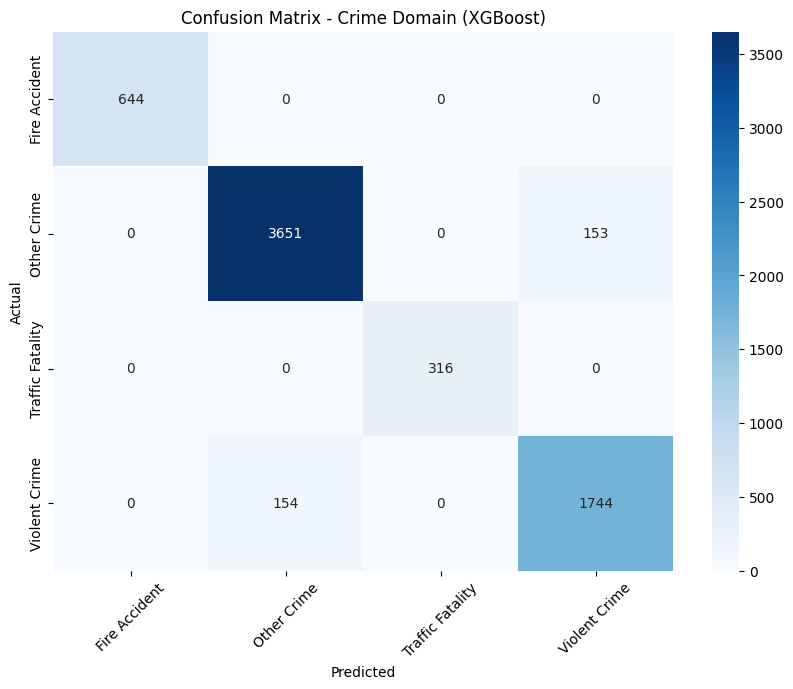

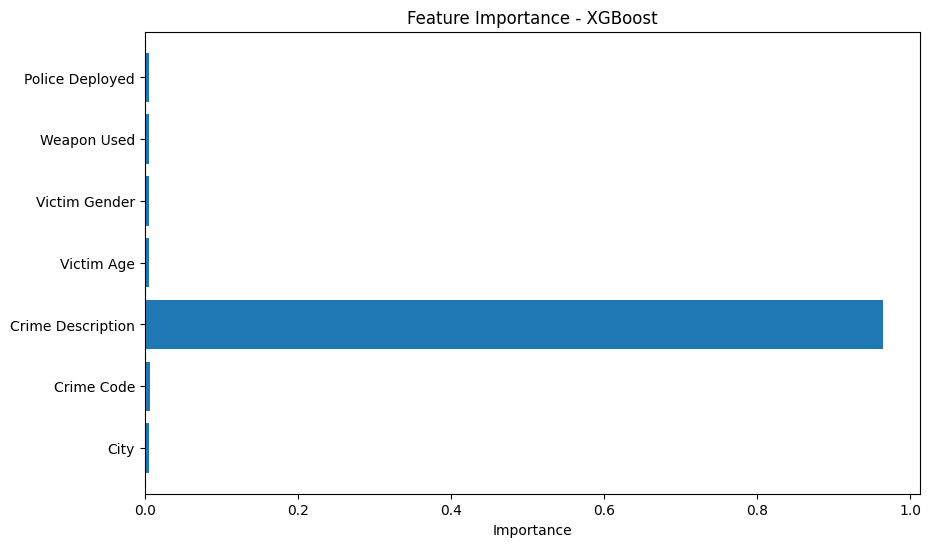

In [ ]:
# ==============================
# XGBOOST - CRIME DOMAIN
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# STEP 1: Load Dataset
df = pd.read_csv("cleaned_crime_dataset_india.csv")

# STEP 2: Drop Leakage / Irrelevant Columns
leak_cols = [
    "Report Number",
    "Date Reported",
    "Date of Occurrence",
    "Time of Occurrence",
    "Date Case Closed",
    "Case Closed",
    "Crime Subcategory",
    "Crime Type",
    "Offense Classification"
]

df.drop(columns=[c for c in leak_cols if c in df.columns], inplace=True)

# STEP 3: Define Target
target_col = "Crime Domain"

X = df.drop(columns=[target_col])
y = df[target_col]

# STEP 4: Train-Test Split (Before Encoding)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# STEP 5: Frequency Encoding for Categorical Columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

def frequency_encode(train, test, cols):
    train_enc = train.copy()
    test_enc = test.copy()

    for col in cols:
        freq = train_enc[col].value_counts(normalize=True)
        train_enc[col] = train_enc[col].map(freq)
        test_enc[col] = test_enc[col].map(freq).fillna(0)

    return train_enc, test_enc

X_train_enc, X_test_enc = frequency_encode(X_train, X_test, cat_cols)

# STEP 6: Handle Missing Values
X_train_enc.fillna(X_train_enc.median(), inplace=True)
X_test_enc.fillna(X_train_enc.median(), inplace=True)

# STEP 7: Encode Target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# STEP 8: Train XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.07,
    subsample=0.85,
    colsample_bytree=0.75,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_enc, y_train_enc)

# STEP 9: Predictions & Evaluation
y_pred = xgb_model.predict(X_test_enc)

accuracy = accuracy_score(y_test_enc, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - Crime Domain (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.show()

# STEP 10: Feature Importance
importances = xgb_model.feature_importances_
features = X_train_enc.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.show()
